<img align="center" src="https://iili.io/3wI8gI.png" style="height:90px" style="width:30px"/>

# Introduction

The purpose of this lab is for you to practice vizualising data!

You will explore 2 different datasets and make visualizations to help explore questions. It is up to you do decide what questions to explore. 

## Dataset 1 | Avocados 

In the csv file `avocado.csv` there is information about weekly sales of Avocados. The dataset has the following columns: 

- Date - The date of the observation
- AveragePrice - the average price of a single avocado
- Total Volume - Total number of avocados sold
- 4046 - Total number of avocados with PLU 4046 sold
- 4225 - Total number of avocados with PLU 4225 sold
- 4770 - Total number of avocados with PLU 4770 sold
- Total Bags - Total number of bags sold. A bag is either Small, Large or X-Large
- Small Bags - Number of small bags sold
- Large Bags - Number of large bags sold
- XLarge Bags - Number of XLarge bags sold
- type - conventional or organic
- year - year sold
- region - the city or region of the sale

#### Formulate at least 5 questions that you want answered. 

Write down your questions in this text cell: 

- Question 1: price per avocato across a year in average and average across all years (if it has big changes)
- Question 2: type of avocado per region, PLU + type (if some regions prefer diff types)
- Question 3: number of avocado sold over the years (positive on negative trend)
- Question 4: types of bags per region and over the years (if there are favourite and/or peoples taste are changing)
- Question 5: price per type PLU and type
- ...?

#### Visualize your findings!

Guidelines for your visualizations: 
- Decide which graph you think is most suitable for the thing you are trying to explain/understand
- Do your best to make your graphs beautiful
- Make sure to add explanatory text to your graph

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
df = pd.read_csv("avocado.csv")
df["Datbbe"] = pd.to_datetime(df["Date"])

## Q1
### - Question 1: price per avocato across a year in average and average across all years (if it has big changes)


In [57]:
df.columns
df.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,month,Datbbe
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,12,2015-12-27
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,12,2015-12-20
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,12,2015-12-13
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,12,2015-12-06
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,11,2015-11-29


In [10]:
df["year"].unique()

array([2015, 2016, 2017, 2018])

<BarContainer object of 12 artists>

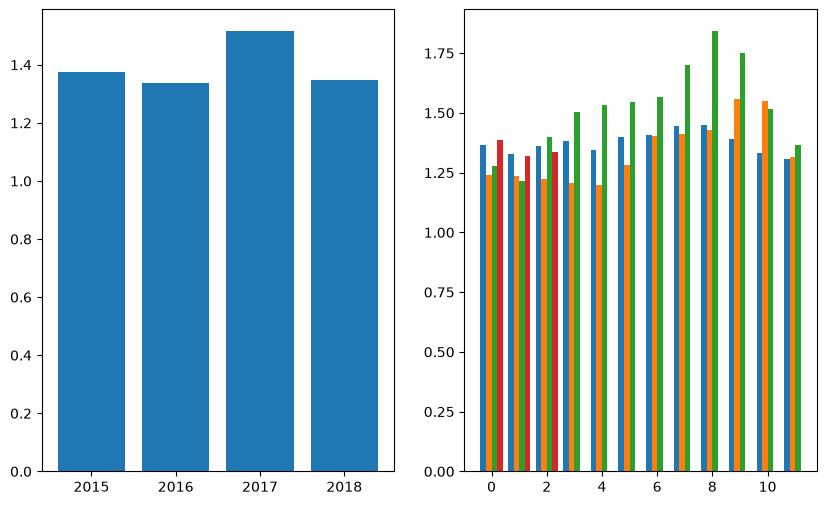

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6))

prc_by_year = df.groupby("year")["AveragePrice"].mean()

ax[0].bar(prc_by_year.index, prc_by_year.values)

df["Date"] = pd.to_datetime(df["Date"])

df["month"] = df["Date"].dt.month
x = np.arange(len(df["month"].unique()))
bar_width = 0.2


ax[1].bar(x - 1.5 * bar_width,df.loc[df["year"]==2015].groupby("month")["AveragePrice"].mean() , width=bar_width)
ax[1].bar(x - 0.5 * bar_width,df.loc[df["year"]==2016].groupby("month")["AveragePrice"].mean() , width=bar_width)
ax[1].bar(x + 0.5 * bar_width,df.loc[df["year"]==2017].groupby("month")["AveragePrice"].mean() , width=bar_width)
ax[1].bar(x + 1.5 * bar_width,df.loc[df["year"]==2018].groupby("month")["AveragePrice"].mean().reindex(range(1,13)) , width=bar_width)



In [36]:
df.groupby("month")["AveragePrice"].mean()

month
1     1.311019
2     1.274387
3     1.332255
4     1.374380
5     1.346601
6     1.408964
7     1.462077
8     1.512514
9     1.572654
10    1.579683
11    1.455563
12    1.331112
Name: AveragePrice, dtype: float64

## Q2

### - Question 2: type of avocado per region, PLU + type (if some regions prefer diff types)


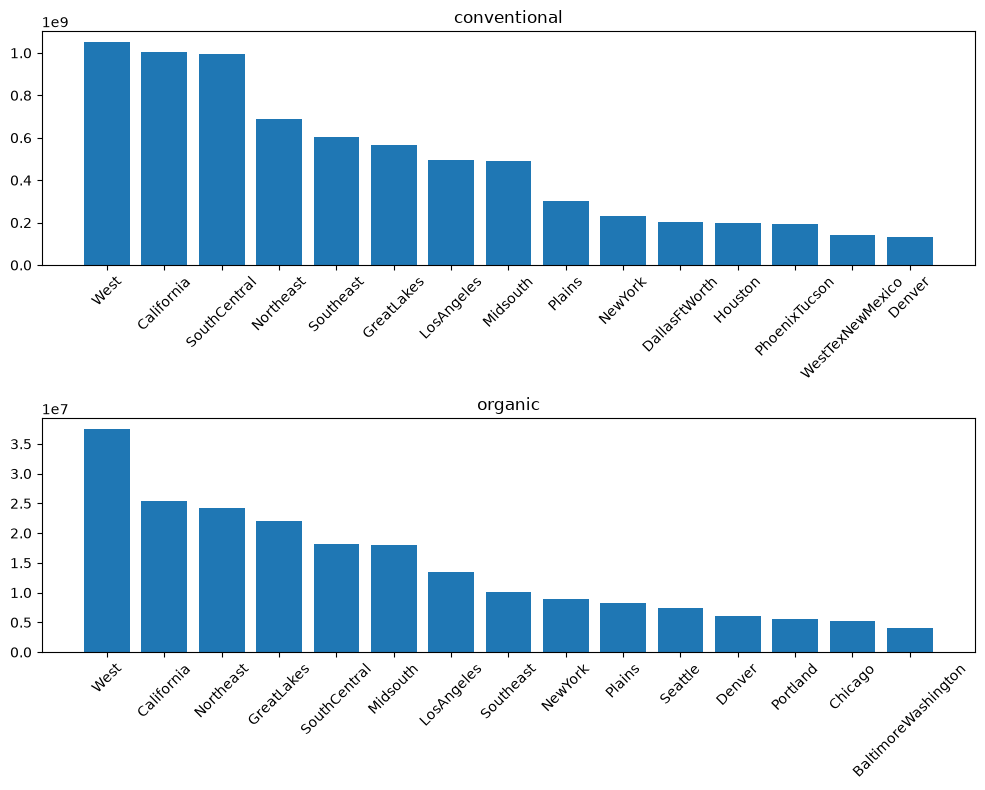

In [84]:

fig, ax = plt.subplots(2, figsize=(10, 8))
i = 0

for type in df["type"].unique():
    data = df.loc[(df["type"] == type) & ~(df["region"] == "TotalUS")].groupby("region")["Total Volume"].sum().nlargest(15)
    ax[i].set_title(type)
    ax[i].tick_params(axis="x",rotation=45)
    ax[i].bar(data.index, data.values)
    i += 1
plt.tight_layout()
plt.show()

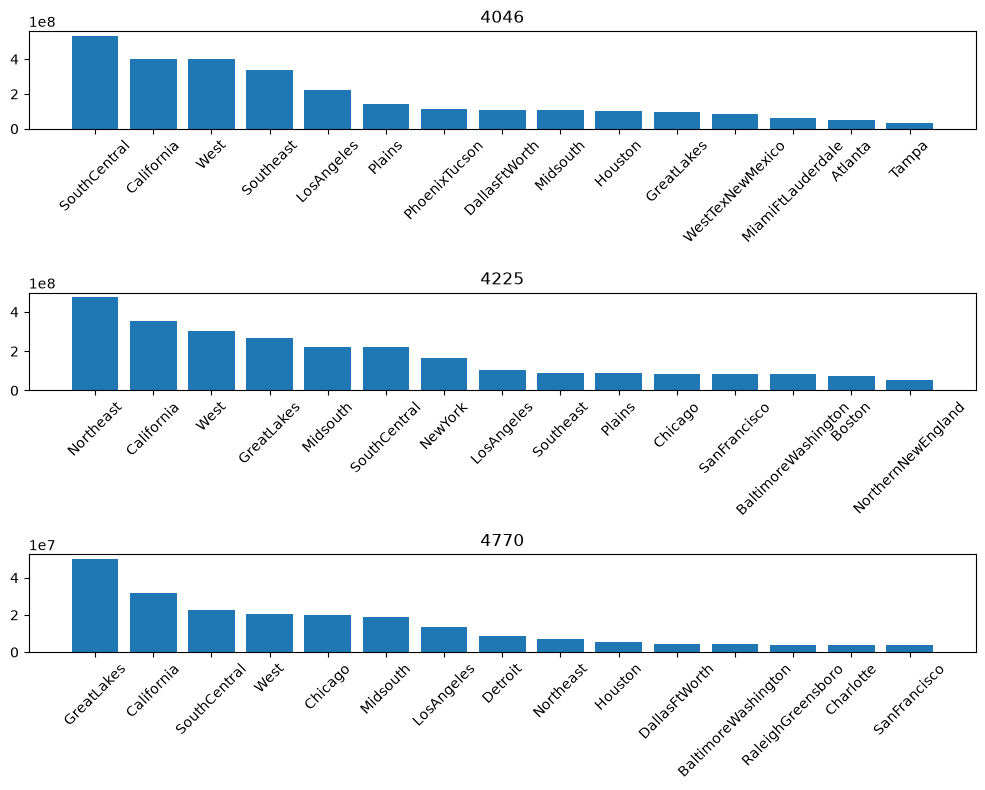

In [92]:
PLU_list = ['4046', '4225', '4770']
fig, ax = plt.subplots(3, figsize=(10, 8))
i = 0
for plu in PLU_list:
    data = df.loc[~(df["region"] == "TotalUS")][[plu,"region"]].groupby("region")[plu].sum().nlargest(15)
    ax[i].set_title(plu)
    ax[i].tick_params(axis="x",rotation=45)
    ax[i].bar(data.index, data.values)
    i += 1
plt.tight_layout()
plt.show()



In [71]:
df.columns

Index(['Date', 'AveragePrice', 'Total Volume', '4046', '4225', '4770',
       'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'type', 'year',
       'region', 'month', 'Datbbe'],
      dtype='str')

- Question 3: number of avocado sold over the years (positive on negative trend)


## Dataset 2 | NBA2020 

In the csv file `nba2020.csv` you will find information about players registered in the NBA year 2020. The columns in the dataset are in general self-explanatory so we won't list them below. If you are unsure about the meaning of a column, don't hesitate to ask. 

#### Formulate at least 5 questions that you want answered. 

Write down your questions in this text cell: 

Write down your questions in this text cell: 

- Question 1:
- Question 2:
- Question 3
- Question 4:
- Question 5:
- ...?

#### Visualize your findings!

Guidelines for your visualizations: 
- Decide which graph you think is most suitable for the thing you are trying to explain/understand
- Do your best to make your graphs beatiful
- Make sure to add explanatory text to your graph